In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [3]:
df.shape

(50000, 20)

In [4]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'account_age_months',
       'subscription_type', 'monthly_fee', 'payment_method', 'primary_device',
       'devices_used', 'favorite_genre', 'avg_watch_time_minutes',
       'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate',
       'rating_given', 'content_interactions', 'recommendation_click_rate',
       'days_since_last_login', 'churned'],
      dtype='str')

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop_duplicates()

In [7]:
df.isnull().sum()

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64

In [17]:
df.columns = df.columns.str.replace(" ", "")

In [18]:
print(df.columns)

Index(['user_id', 'age', 'gender', 'country', 'account_age_months',
       'subscription_type', 'monthly_fee', 'payment_method', 'primary_device',
       'devices_used', 'favorite_genre', 'avg_watch_time_minutes',
       'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate',
       'rating_given', 'content_interactions', 'recommendation_click_rate',
       'days_since_last_login', 'churned'],
      dtype='str')


In [19]:
df['favorite_genre'].value_counts()

favorite_genre
Documentary    6352
Romance        6282
Comedy         6259
Thriller       6257
Action         6235
Horror         6223
Drama          6203
Sci-Fi         6189
Name: count, dtype: int64

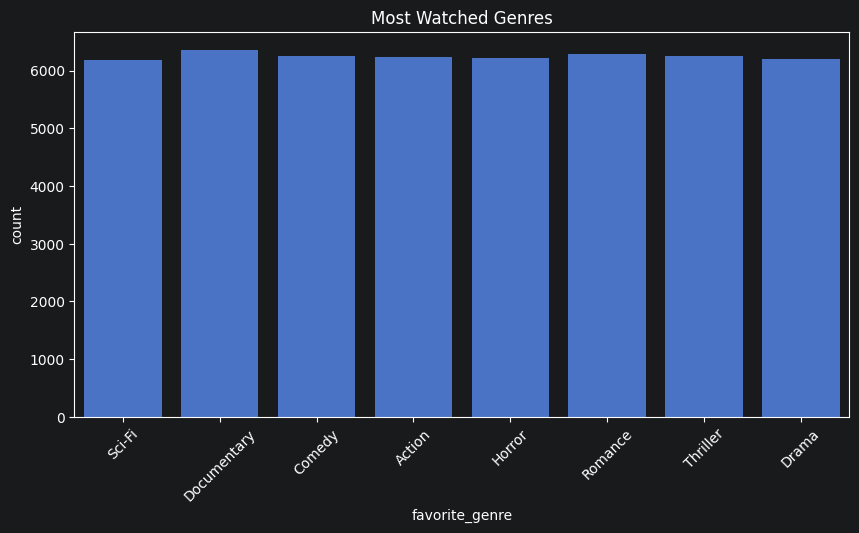

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='favorite_genre', data=df)
plt.title("Most Watched Genres")
plt.xticks(rotation=45)
plt.show()

In [21]:
df['subscription_type'].value_counts()

subscription_type
Standard    19931
Premium     15196
Basic       14873
Name: count, dtype: int64

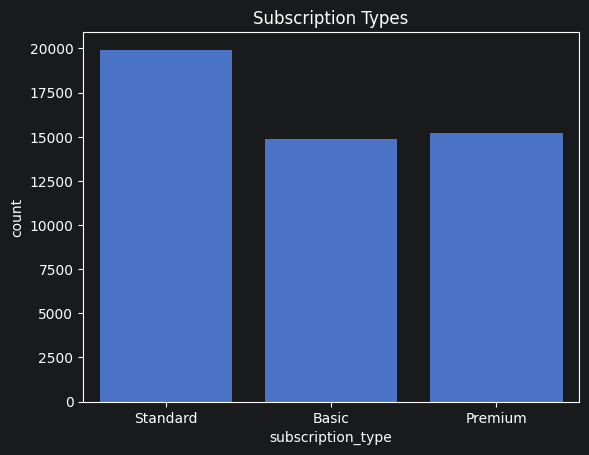

In [22]:
sns.countplot(x='subscription_type', data=df)
plt.title("Subscription Types")
plt.show()

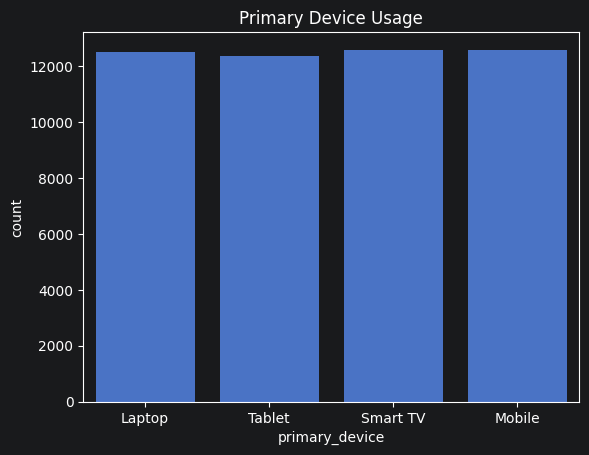

In [23]:
sns.countplot(x='primary_device', data=df)
plt.title("Primary Device Usage")
plt.show()

In [24]:
df['avg_watch_time_minutes'].mean()

np.float64(154.94652)

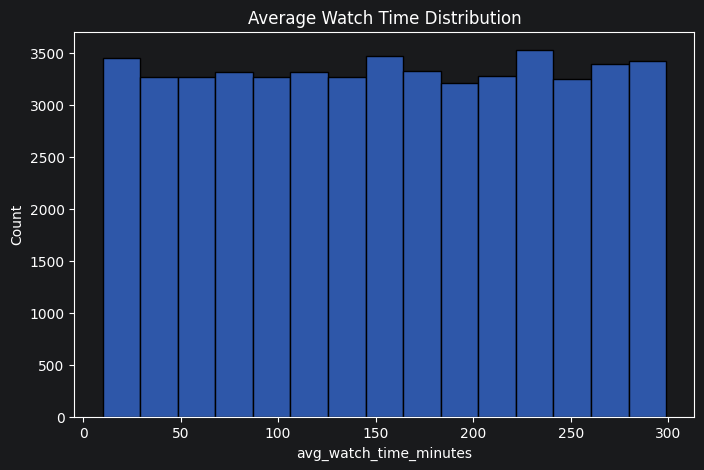

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['avg_watch_time_minutes'], bins=15)
plt.title("Average Watch Time Distribution")
plt.show()

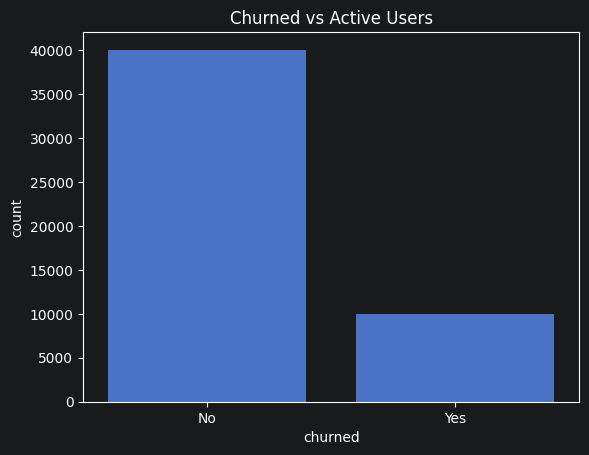

In [26]:
sns.countplot(x='churned', data=df)
plt.title("Churned vs Active Users")
plt.show()

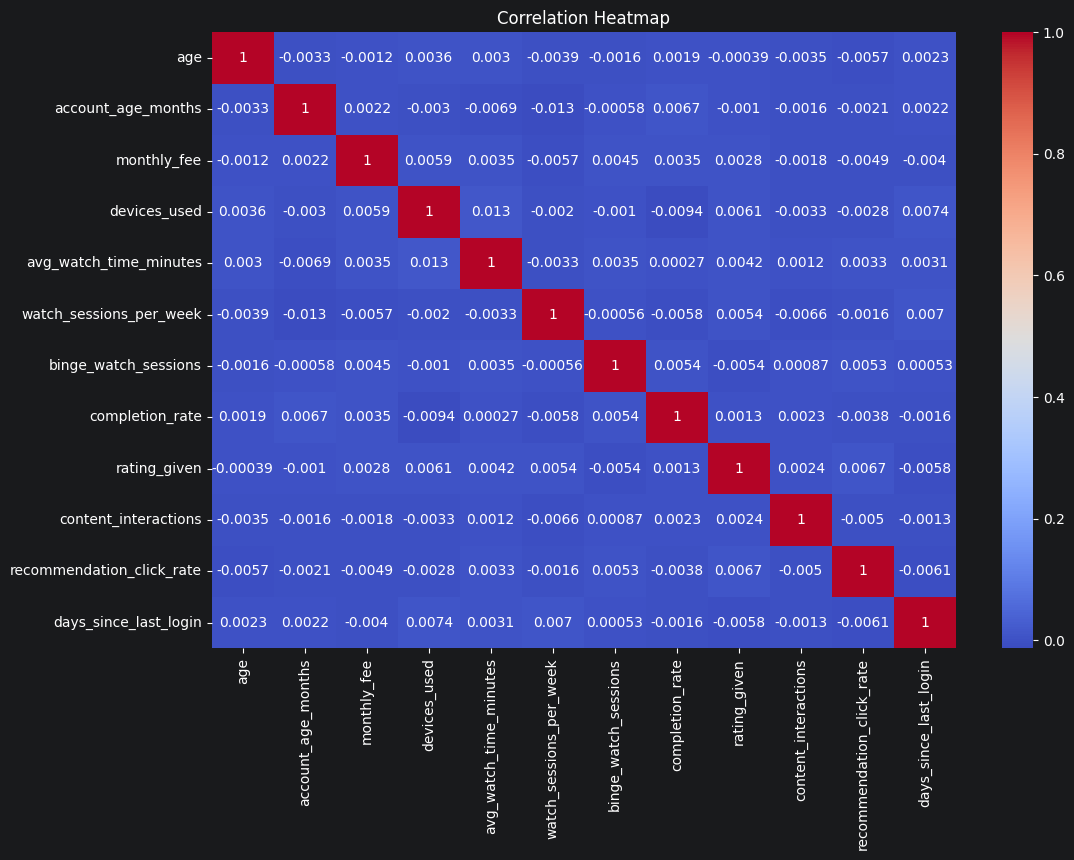

In [27]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

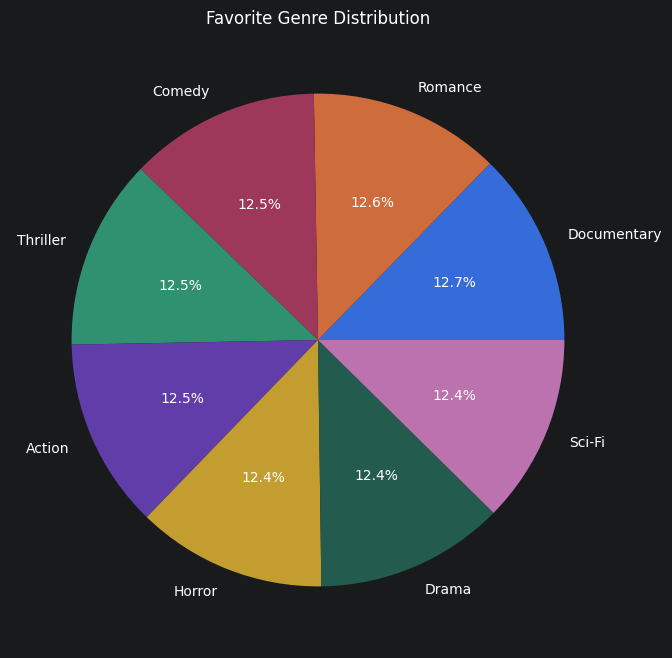

In [28]:
genre_counts = df['favorite_genre'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(genre_counts,
        labels=genre_counts.index,
        autopct='%1.1f%%')
plt.title("Favorite Genre Distribution")
plt.show()

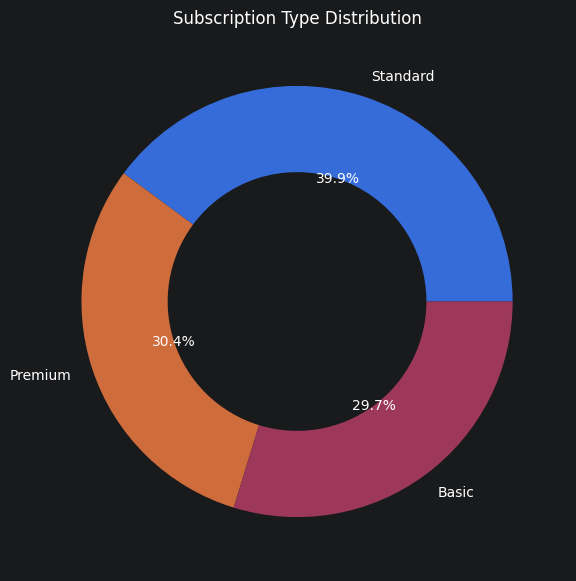

In [29]:
sub_counts = df['subscription_type'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(sub_counts,
        labels=sub_counts.index,
        autopct='%1.1f%%',
        wedgeprops={'width':0.4})
plt.title("Subscription Type Distribution")
plt.show()

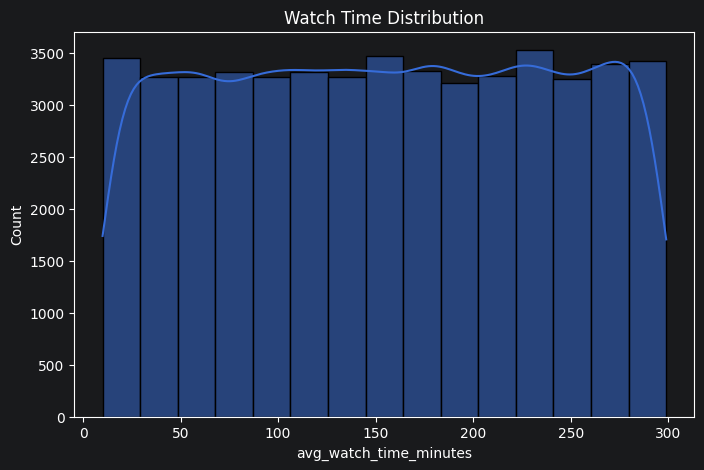

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['avg_watch_time_minutes'],
             bins=15,
             kde=True)
plt.title("Watch Time Distribution")
plt.show()

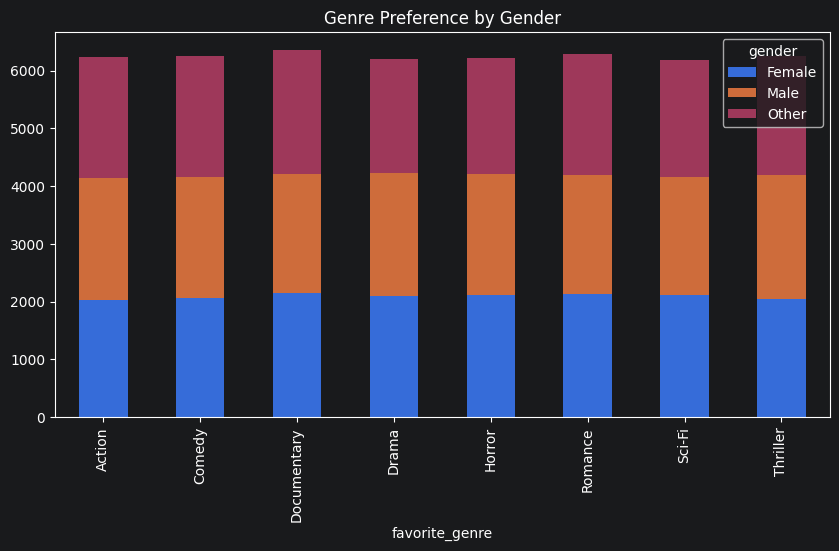

In [31]:
pd.crosstab(df['favorite_genre'],
            df['gender']).plot(kind='bar',
                               stacked=True,
                               figsize=(10,5))
plt.title("Genre Preference by Gender")
plt.show()

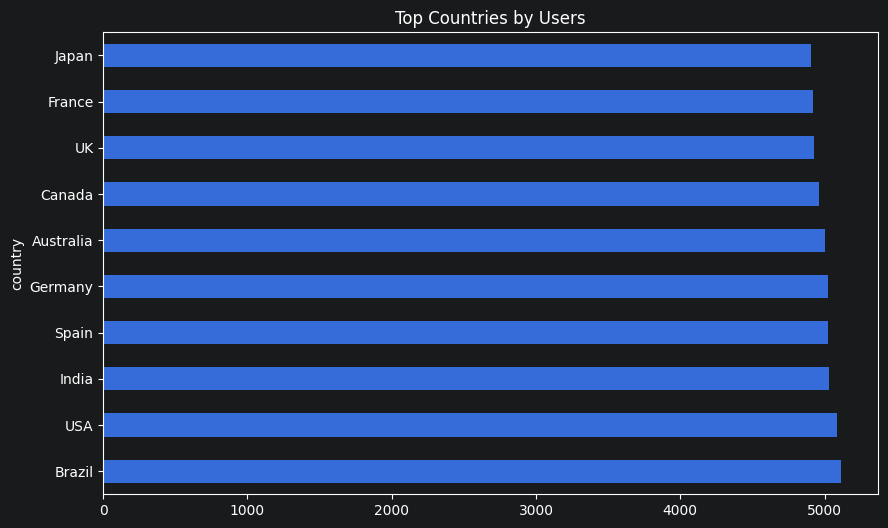

In [34]:
country_counts = df['country'].value_counts().head(10)
country_counts.plot(kind='barh',
                    figsize=(10,6))
plt.title("Top Countries by Users")
plt.show()

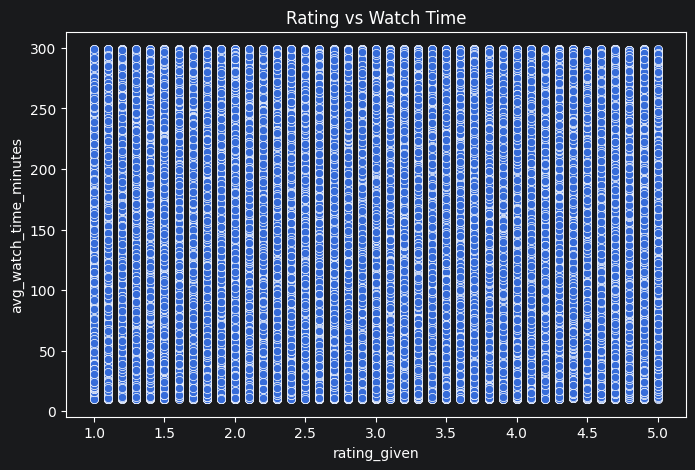

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='rating_given',
                y='avg_watch_time_minutes',
                data=df)
plt.title("Rating vs Watch Time")
plt.show()

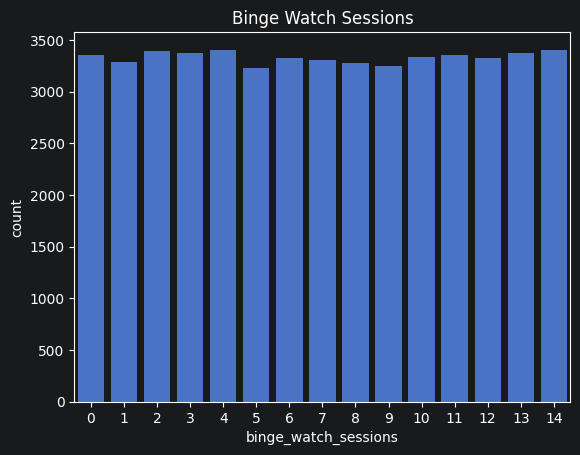

In [36]:
sns.countplot(x='binge_watch_sessions', data=df)
plt.title("Binge Watch Sessions")
plt.show()

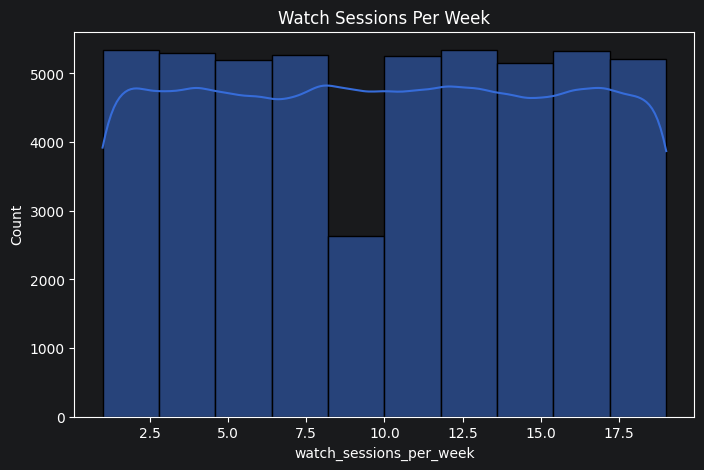

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['watch_sessions_per_week'],
             bins=10,
             kde=True)
plt.title("Watch Sessions Per Week")
plt.show()

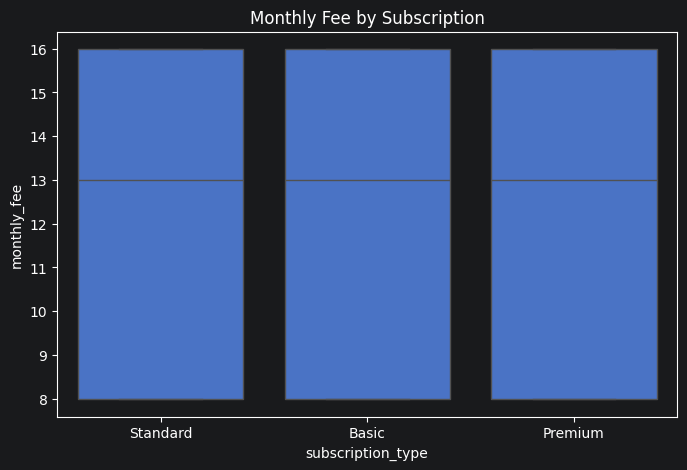

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x='subscription_type',
            y='monthly_fee',
            data=df)
plt.title("Monthly Fee by Subscription")
plt.show()

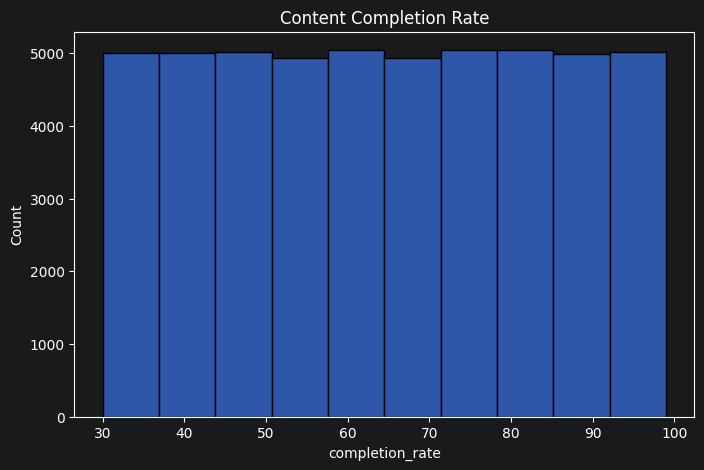

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['completion_rate'],
             bins=10)
plt.title("Content Completion Rate")
plt.show()

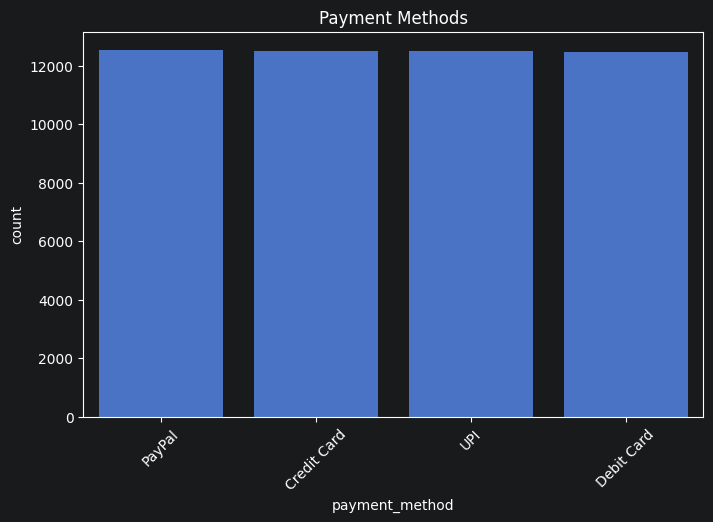

In [41]:
plt.figure(figsize=(8,5))
sns.countplot(x='payment_method',
              data=df)
plt.title("Payment Methods")
plt.xticks(rotation=45)
plt.show()

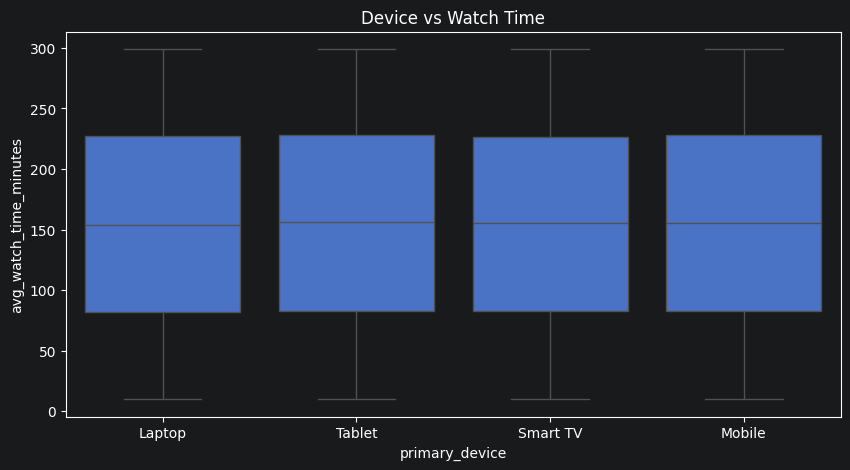

In [42]:
plt.figure(figsize=(10,5))
sns.boxplot(x='primary_device',
            y='avg_watch_time_minutes',
            data=df)
plt.title("Device vs Watch Time")
plt.show()

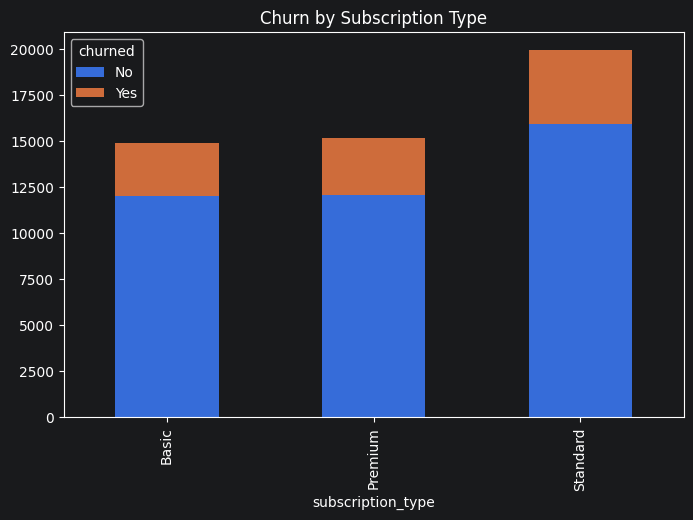

In [43]:
pd.crosstab(df['subscription_type'],
            df['churned']).plot(kind='bar',
                                stacked=True,
                                figsize=(8,5))
plt.title("Churn by Subscription Type")
plt.show()

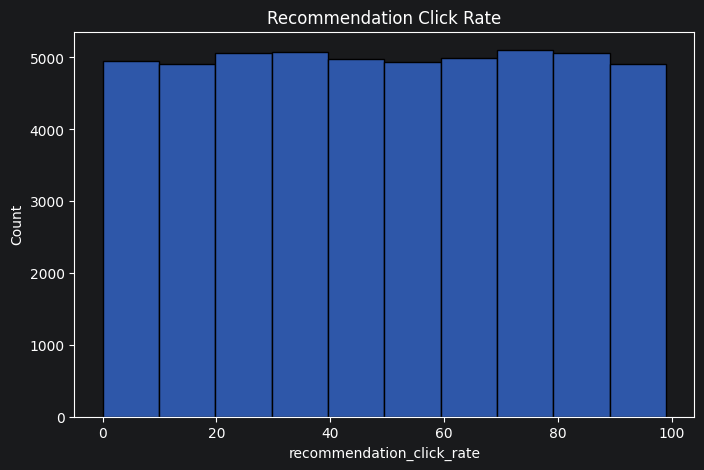

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df['recommendation_click_rate'],
             bins=10)
plt.title("Recommendation Click Rate")
plt.show()